In [29]:
import polars as pl
import pandas as pd
import numpy as mp
import altair as alt
import pyarrow
from pyarrow import dictionary

from func.UsefulFunctions import *

In [30]:
groupDF = pl.read_parquet("Data/pipelinedGroupsWikidata.parquet")
groupDF.head()

group,groupLabel,genre,groupType,inception,countryOfOrigin,recordLabel,genreLabel,groupTypeLabel,countryOfOriginLabel,recordLabelLabel,influencedby,influencedbyLabel,musicBrainzID,article,statementCount,__index_level_0__
str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,f64,i64
"""Q72092""","""Rage Against the Machine""","""Q877693""","""Q215380""",2001.0,"""Q30""","""Q216364""","""rap rock""","""musical group""","""United States""","""Epic Records""","""Q924413""","""24-7 Spyz""","""3798b104-01cb-484c-a3b0-56adc6…","""https://en.wikipedia.org/wiki/…",125.0,0
"""Q72092""","""Rage Against the Machine""","""Q877693""","""Q215380""",2001.0,"""Q30""","""Q216364""","""rap rock""","""musical group""","""United States""","""Epic Records""","""Q392""","""Bob Dylan""","""3798b104-01cb-484c-a3b0-56adc6…","""https://en.wikipedia.org/wiki/…",125.0,1
"""Q72092""","""Rage Against the Machine""","""Q877693""","""Q215380""",2001.0,"""Q30""","""Q216364""","""rap rock""","""musical group""","""United States""","""Epic Records""","""Q10708""","""Red Hot Chili Peppers""","""3798b104-01cb-484c-a3b0-56adc6…","""https://en.wikipedia.org/wiki/…",125.0,2
"""Q72092""","""Rage Against the Machine""","""Q877693""","""Q215380""",2001.0,"""Q30""","""Q216364""","""rap rock""","""musical group""","""United States""","""Epic Records""","""Q622947""","""Jane's Addiction""","""3798b104-01cb-484c-a3b0-56adc6…","""https://en.wikipedia.org/wiki/…",125.0,3
"""Q72092""","""Rage Against the Machine""","""Q877693""","""Q215380""",2001.0,"""Q30""","""Q216364""","""rap rock""","""musical group""","""United States""","""Epic Records""","""Q464476""","""Black Flag""","""3798b104-01cb-484c-a3b0-56adc6…","""https://en.wikipedia.org/wiki/…",125.0,4


In [31]:
groupDF.schema

Schema([('group', String),
        ('groupLabel', String),
        ('genre', String),
        ('groupType', String),
        ('inception', Float64),
        ('countryOfOrigin', String),
        ('recordLabel', String),
        ('genreLabel', String),
        ('groupTypeLabel', String),
        ('countryOfOriginLabel', String),
        ('recordLabelLabel', String),
        ('influencedby', String),
        ('influencedbyLabel', String),
        ('musicBrainzID', String),
        ('article', String),
        ('statementCount', Float64),
        ('__index_level_0__', Int64)])

In [32]:
#Look at the size of the dataset
size = groupDF.select(pl.col("group")).unique()
print(f"There are {len(size)} groups in this dataset")

There are 125699 groups in this dataset


In [33]:
#What are the unique group types
groupDF.select(
    pl.col(["groupType", "groupTypeLabel"])
).unique().write_csv("variousGroupTypes.csv")


In [34]:
#Drop everyone who is fictitious as no characters are allowed
#Get all the people who have have fictitious in there
characterEntities= groupDF.filter(
    pl.col("groupTypeLabel").str.contains("(?i)fictional")
).select(pl.col("group")).unique()

#drop everyone who is not fictional and deduplicate
groupDF = groupDF.filter(
    ~pl.col("group").is_in(characterEntities["group"].implode())
).unique()


print(f"There are {len(groupDF["group"].unique())} groups in this dataset")




There are 125650 groups in this dataset


In [35]:
def nullColumnLabelWithissues(df, column):
    columnLabel = column + "Label"

    noLabel = df.filter(
        pl.col(column).is_in(pl.col(columnLabel).implode())
    ).select(pl.col(columnLabel)).unique()
    noLabel_dict= {k: None for k in noLabel[columnLabel].to_list()}
    df = df.with_columns(pl.col(columnLabel).replace(noLabel_dict))

    nolabelDF = df.filter(
        pl.col(columnLabel).is_null(),
    ).select(pl.col(["group","groupLabel"])).unique()
    display(nolabelDF)
    print(f"There are {len(nolabelDF)} groups with no default labels/labels in english in Column: {columnLabel}.")
    if column == "genre":
        nolabelDF.write_csv(f"./missingValuesStore/groupEntitiesWithoutLabels.csv")
    else:
        nolabelDF.write_csv(f"./missingValuesStore/groupEntitiesWithoutLabelled{column}OrNo{column}.csv")

    return df


In [36]:
#Null the group name labels for the groups who do not have a group label
groupDF = nullColumnLabelWithissues(groupDF, "group")

group,groupLabel
str,str
"""Q121028122""",null
"""Q16171179""",null
"""Q136694473""",null
"""Q16097709""",null
"""Q131275200""",null
…,…
"""Q104819344""",null
"""Q85978787""",null
"""Q54820104""",null


There are 15927 groups with no default labels/labels in english in Column: groupLabel.


In [37]:
#Check the genres and the genreLabels - Cleaned previously in the pipline stage, to remove error ones
#No genre added had no name
groupDF.filter(
    pl.col("genre").is_in(pl.col("genreLabel").implode())
)
#create a list of artists with no labelled genres or no genres
entitiesWithNullGenres = groupDF.filter(
    pl.col("genreLabel").is_null()
).select(pl.col(["group","groupLabel"])).unique()
display(entitiesWithNullGenres)
entitiesWithNullGenres.write_csv("./missingValuesStore/groupEntitiesWithoutLabelledGenresOrNoGenres.csv")


group,groupLabel
str,str
"""Q904700""",null
"""Q1710753""",null
"""Q111210408""",null
"""Q85867908""",null
"""Q10356847""","""RZO"""
…,…
"""Q15932968""",null
"""Q3526742""","""Volumia!"""
"""Q5050968""","""Cat's Eyes"""


In [38]:
groupDF.filter(
    pl.col("genre").is_in(pl.col("genreLabel").implode())
)

group,groupLabel,genre,groupType,inception,countryOfOrigin,recordLabel,genreLabel,groupTypeLabel,countryOfOriginLabel,recordLabelLabel,influencedby,influencedbyLabel,musicBrainzID,article,statementCount,__index_level_0__
str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,f64,i64


In [39]:
#Check the group Types. In pipeline stage already removed groupTypes that had no Q number from pipeline
groupDF = nullColumnLabelWithissues(groupDF, "groupType")

group,groupLabel
str,str
"""Q12073705""",null
"""Q15825100""",null
"""Q5846519""","""Sociedad Coral de Bilbao"""
"""Q1593585""","""Army Band Hannover"""
"""Q136565013""","""Martin-Luther-Kantorei"""
…,…
"""Q12099573""","""Darnychanka"""
"""Q1802266""",null
"""Q138659231""",null


There are 65 groups with no default labels/labels in english in Column: groupTypeLabel.


In [40]:
#Check the countryOfOrign. In pipeline stage already removed countryOfOrigin that had no Q number from earlier
groupDF = nullColumnLabelWithissues(groupDF, "countryOfOrigin")

group,groupLabel
str,str
"""Q65015375""","""Oliver Berney Eric Gigante Qui…"
"""Q21558039""","""Victor Orchestra"""
"""Q28468126""","""Rudess/Morgenstein Project"""
"""Q16959845""","""Las Acevedo"""
"""Q29336458""",null
…,…
"""Q24229349""","""Way Station"""
"""Q10412941""","""Ansambl Urošević"""
"""Q18477829""",null


There are 34900 groups with no default labels/labels in english in Column: countryOfOriginLabel.


In [41]:
#Check the recordLabel and influencedby. As with the other fields the non-Q-numbers were removed
groupDF = nullColumnLabelWithissues(groupDF, "recordLabel")
groupDF = nullColumnLabelWithissues(groupDF, "influencedby")

group,groupLabel
str,str
"""Q2558633""","""Cliffhanger"""
"""Q125821540""","""Eddy and the Soul Band"""
"""Q55423986""","""Kadnay"""
"""Q60670323""",null
"""Q105318402""",null
…,…
"""Q115624752""","""The Bird Jazz Band"""
"""Q5712529""","""Hemophiliac"""
"""Q681669""","""Pokolgép"""


There are 101923 groups with no default labels/labels in english in Column: recordLabelLabel.


group,groupLabel
str,str
"""Q55637021""","""Vein.fm"""
"""Q63536453""","""Alpenstrolche"""
"""Q25469815""","""Barasuara"""
"""Q28501728""","""Cuchillazo"""
"""Q3074639""","""Flying pooh"""
…,…
"""Q827981""","""Old and in the Way"""
"""Q16353920""","""Crowd"""
"""Q2599252""","""Yambalaya"""


There are 125034 groups with no default labels/labels in english in Column: influencedbyLabel.


In [42]:
#Look at the musicBrainz IDs to confirm that there isn't an issue observed, and it was fixed in the pipeline
groupDF.filter(
    (pl.col("musicBrainzID").str.contains("http")) | (pl.col("musicBrainzID").str.contains("user")) | (pl.col("musicBrainzID").str.contains("artist"))
)

group,groupLabel,genre,groupType,inception,countryOfOrigin,recordLabel,genreLabel,groupTypeLabel,countryOfOriginLabel,recordLabelLabel,influencedby,influencedbyLabel,musicBrainzID,article,statementCount,__index_level_0__
str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,f64,i64


In [43]:
#Looked at the article column to confirm that the filters in the pipeline column worked correctly and only returned proper links
groupDF.filter(
    ~pl.col("article").str.contains("(?i)en.wikipedia")
)

group,groupLabel,genre,groupType,inception,countryOfOrigin,recordLabel,genreLabel,groupTypeLabel,countryOfOriginLabel,recordLabelLabel,influencedby,influencedbyLabel,musicBrainzID,article,statementCount,__index_level_0__
str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,f64,i64


In [44]:
#Change the inception column to years
groupsWithNoInception = groupDF.filter(
    pl.col("inception").is_null()
).select(['group','groupLabel']).unique()
print(f"There are {len(groupsWithNoInception)} groups with no inception year.")
groupsWithNoInception.write_csv("./missingValuesStore/groupEntitiesWithNoInceptionYear.csv")

There are 76962 groups with no inception year.


In [45]:
groupDF.write_parquet("./Data/Network_groupWikidata.parquet")

In [46]:
groupDF.filter(
    pl.col("influencedby").is_not_null()
)

group,groupLabel,genre,groupType,inception,countryOfOrigin,recordLabel,genreLabel,groupTypeLabel,countryOfOriginLabel,recordLabelLabel,influencedby,influencedbyLabel,musicBrainzID,article,statementCount,__index_level_0__
str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,f64,i64
"""Q134233""","""Jonas Brothers""","""Q37073""","""Q215380""",2019.0,"""Q30""","""Q2604329""","""pop music""","""musical group""","""United States""","""Fascination""","""Q485811""","""Fall Out Boy""","""6e019bc6-5c23-4935-94f0-4a8966…","""https://en.wikipedia.org/wiki/…",142.0,7636
"""Q1299""","""The Beatles""","""Q83270""","""Q215380""",1960.0,"""Q145""","""Q208909""","""hard rock""","""musical group""","""United Kingdom""","""Parlophone""","""Q82222""","""Little Richard""","""b10bbbfc-cf9e-42e0-be17-e2c3e1…","""https://en.wikipedia.org/wiki/…",370.0,133676
"""Q673364""","""Obrint Pas""","""Q11399""","""Q215380""",null,"""Q29""","""Q9063194""","""rock music""","""musical group""","""Spain""","""Propaganda pel Fet!""","""Q2306388""","""Al Tall""","""cf23db24-d797-4fcf-929a-e03a8e…","""https://en.wikipedia.org/wiki/…",56.0,9100
"""Q18233""","""ABBA""","""Q76092""","""Q215380""",2016.0,"""Q34""","""Q7697852""","""glam rock""","""musical group""","""Sweden""","""Telstar""","""Q211277""","""The Mamas & the Papas""","""d87e52c5-bb8d-4da8-b941-9f4928…","""https://en.wikipedia.org/wiki/…",551.0,148003
"""Q740434""","""Smash Mouth""","""Q460674""","""Q5741069""",1994.0,"""Q30""","""Q4120935""","""ska punk""","""rock band""","""United States""","""429 Records""","""Q47871""","""Green Day""","""944e1036-8a03-4611-8aa0-31515a…","""https://en.wikipedia.org/wiki/…",122.0,26282
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Q1155385""","""Third Eye Blind""","""Q484641""","""Q215380""",1993.0,"""Q30""","""Q21077""","""pop rock""","""musical group""","""United States""","""Warner Music Group""","""Q622947""","""Jane's Addiction""","""92a42e82-b36f-4308-82c1-68bad2…","""https://en.wikipedia.org/wiki/…",100.0,39868
"""Q136521690""","""Feed the Beast""","""Q483352""","""Q215380""",null,"""Q30""",null,"""thrash metal""","""musical group""","""United States""",null,"""Q199418""","""Ziggy Marley""",null,null,30.0,129471
"""Q18233""","""ABBA""","""Q1374731""","""Q29881657""",2018.0,"""Q34""","""Q155152""","""Eurodisco""","""vocal-musical ensemble""","""Sweden""","""Polydor Records""","""Q213793""","""Phil Spector""","""d87e52c5-bb8d-4da8-b941-9f4928…","""https://en.wikipedia.org/wiki/…",551.0,140226


In [47]:
#How many groups are there
print(len(groupDF['group'].unique()))

125650


There are 90751 groups with regions.
There are 34899 groups with no regions.


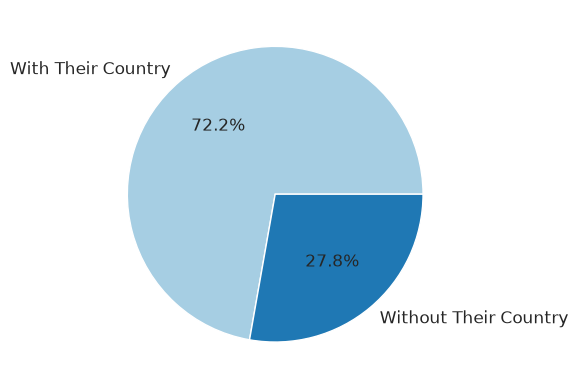

In [48]:
#Country of Origin

#groups with no country of origin
noRegion = groupDF.filter(
    pl.col("countryOfOrigin").is_null()
).select(pl.col("group")).unique()

hasRegion = groupDF.filter(
    pl.col("countryOfOrigin").is_not_null()
).select(pl.col("group")).unique()

print(f"There are {len(hasRegion)} groups with regions.")
print(f"There are {len(noRegion)} groups with no regions.")

plt.rc("font", size=12)
makePieChart(["With Their Country", "Without Their Country"], [len(hasRegion), len(noRegion)], "Groups With and Without Their Country of Origin on Wikidata", "Paired")


There are 40114 groups with regions on wikipedia.
There are 10309 groups with no regions on wikipedia.


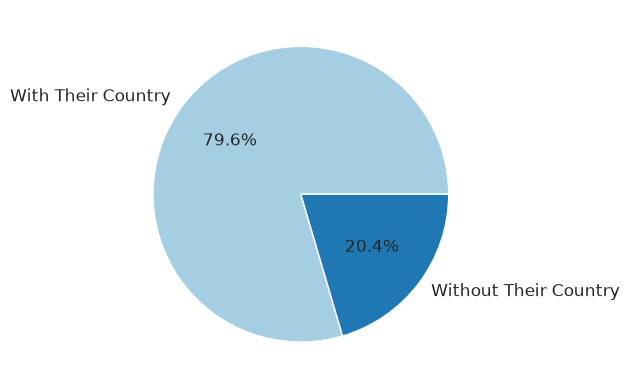

In [49]:
#Country of Origin

#groups with no country of origin
noRegion = groupDF.filter(
    pl.col("countryOfOrigin").is_null(),
    pl.col("article").is_not_null(),
).select(pl.col("group")).unique()

hasRegion = groupDF.filter(
    pl.col("countryOfOrigin").is_not_null(),
    pl.col("article").is_not_null(),
).select(pl.col("group")).unique()

print(f"There are {len(hasRegion)} groups with regions on wikipedia.")
print(f"There are {len(noRegion)} groups with no regions on wikipedia.")

makePieChart(["With Their Country", "Without Their Country"], [len(hasRegion), len(noRegion)], "Groups With and Without Their Country of Origin on Wikipedia", "Paired")

The groups on wikidata cover 270 countries (present and historical).


countryOfOrigin,fraction
str,f64
"""Q30""",0.234551
"""Q145""",0.079646
"""Q17""",0.079395
"""Q183""",0.069989
"""Q33""",0.033794
…,…
"""Q15282""",0.000011
"""Q130229""",0.000011
"""Q846""",0.000011


countryOfOrigin,countryOfOriginLabel,group
str,str,u32
null,null,34899
"""Q30""","""United States""",21495
"""Q145""","""United Kingdom""",7299
"""Q17""","""Japan""",7276
"""Q183""","""Germany""",6414


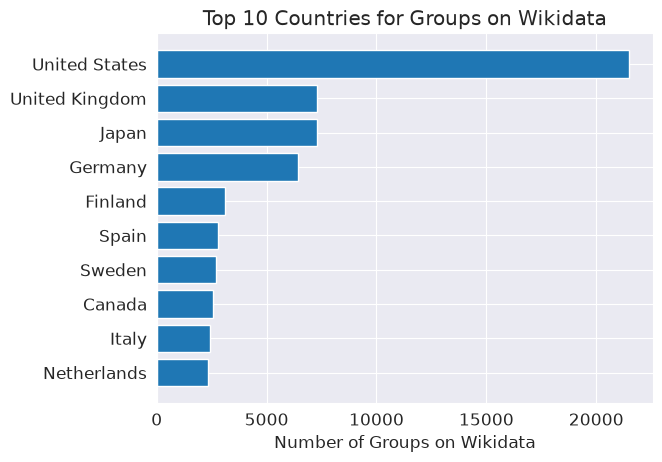

In [50]:
regions = groupDF.select(
    pl.col("group"),
    pl.col("countryOfOrigin"),
    pl.col("countryOfOriginLabel"),
    pl.col("article")
).unique()

print(f"The groups on wikidata cover {len(regions["countryOfOrigin"].drop_nulls().unique())} countries (present and historical).")
regionsGrouped = regions.group_by(["countryOfOrigin", "countryOfOriginLabel"]).agg(pl.col("group").count()).sort(by=pl.col("group"),descending=True)
regionsGroupedFRAC = regions["countryOfOrigin"].drop_nulls().value_counts(sort=True, normalize=True, name="fraction")
display(regionsGroupedFRAC)
regionsGrouped.write_csv("./Visuals Data/groupsGroupedByRegions-Countries.csv", null_value="null/unknown")
display(regionsGrouped.head(5))

top10Regions = regionsGrouped.drop_nulls()[0:10]
horizontalBarChart(top10Regions["countryOfOriginLabel"].to_list(), top10Regions["group"].to_list(), "Top 10 Countries for Groups on Wikidata", "Number of Groups on Wikidata" )

There are 207 countryOfOrigins for groups on Wikipedia.
shape: (207, 2)
┌─────────────────┬──────────┐
│ countryOfOrigin ┆ fraction │
│ ---             ┆ ---      │
│ str             ┆ f64      │
╞═════════════════╪══════════╡
│ Q30             ┆ 0.435052 │
│ Q145            ┆ 0.146657 │
│ Q16             ┆ 0.046628 │
│ Q408            ┆ 0.045144 │
│ Q17             ┆ 0.034291 │
│ …               ┆ …        │
│ Q23635          ┆ 0.000025 │
│ Q19236425       ┆ 0.000025 │
│ Q730            ┆ 0.000025 │
│ Q1778994        ┆ 0.000025 │
│ Q1246           ┆ 0.000025 │
└─────────────────┴──────────┘
shape: (5, 3)
┌─────────────────┬──────────────────────┬───────┐
│ countryOfOrigin ┆ countryOfOriginLabel ┆ group │
│ ---             ┆ ---                  ┆ ---   │
│ str             ┆ str                  ┆ u32   │
╞═════════════════╪══════════════════════╪═══════╡
│ Q30             ┆ United States        ┆ 17597 │
│ null            ┆ null                 ┆ 10309 │
│ Q145            ┆ United Kin

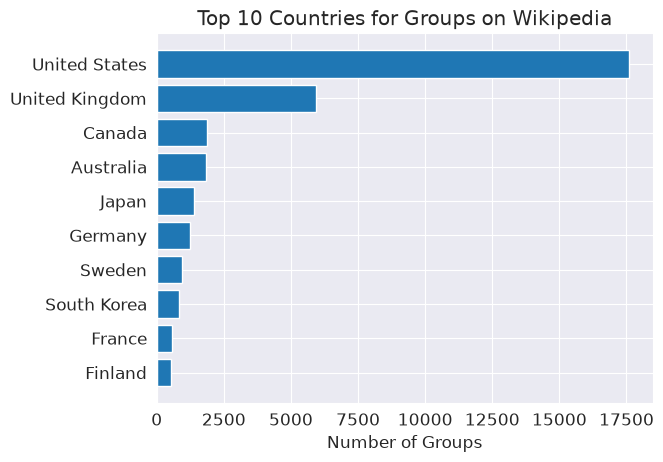

In [51]:
regions = (groupDF
           .filter(
    pl.col("article").is_not_null()
    )
           .select(
    pl.col("group"),
    pl.col("countryOfOrigin"),
    pl.col("countryOfOriginLabel"),
    pl.col("article")
).unique())

makeTop10(regions, "group", "countryOfOrigin", "countryOfOriginLabel", "Wikipedia", "Top 10 Countries for Groups on Wikipedia")

There are 66627 groups with genres on Wikidata.
There are 59023 groups with no genres.


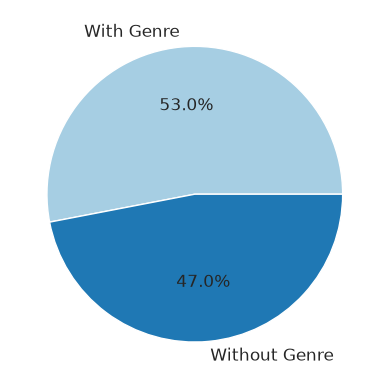

In [52]:
#Find the genres and the lack there of on "Wikidata"

hasGenre = groupDF.filter(pl.col("genre").is_not_null()).select(
    pl.col("group")
).unique()
noGenre = groupDF.filter(pl.col("genre").is_null()).select(
    pl.col("group")
).unique()
print(f"There are {len(hasGenre)} groups with genres on Wikidata.")
print(f"There are {len(noGenre)} groups with no genres.")
makePieChart(["With Genre", "Without Genre"], [len(hasGenre), len(noGenre)], "Groups With and Without Genres on Wikidata", "Paired")

There are 34623 groups with genres on Wikipedia.
There are 15800 groups with no genres.


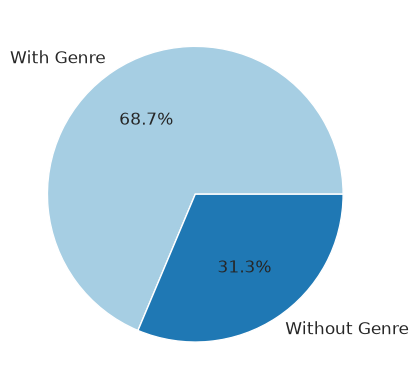

In [53]:
#Find the genres and the lack there of on "Wikidata"

hasGenre = groupDF.filter(
    pl.col("genre").is_not_null(),
    pl.col("article").is_not_null(),
                          ).select(
    pl.col("group")
).unique()
noGenre = groupDF.filter(
    pl.col("genre").is_null(),
    pl.col("article").is_not_null(),).select(
    pl.col("group")
).unique()
print(f"There are {len(hasGenre)} groups with genres on Wikipedia.")
print(f"There are {len(noGenre)} groups with no genres.")
makePieChart(["With Genre", "Without Genre"], [len(hasGenre), len(noGenre)], "Groups With and Without Genres on Wikipedia", "Paired")

There are 1704 genres for groups on Wikidata.
shape: (1_704, 2)
┌───────────┬──────────┐
│ genre     ┆ fraction │
│ ---       ┆ ---      │
│ str       ┆ f64      │
╞═══════════╪══════════╡
│ Q11399    ┆ 0.080367 │
│ Q3071     ┆ 0.05158  │
│ Q11366    ┆ 0.050646 │
│ Q37073    ┆ 0.040434 │
│ Q183504   ┆ 0.034759 │
│ …         ┆ …        │
│ Q1045756  ┆ 0.000011 │
│ Q1503406  ┆ 0.000011 │
│ Q98528189 ┆ 0.000011 │
│ Q2863648  ┆ 0.000011 │
│ Q96395212 ┆ 0.000011 │
└───────────┴──────────┘
shape: (5, 3)
┌────────┬──────────────────┬───────┐
│ genre  ┆ genreLabel       ┆ group │
│ ---    ┆ ---              ┆ ---   │
│ str    ┆ str              ┆ u32   │
╞════════╪══════════════════╪═══════╡
│ null   ┆ null             ┆ 59023 │
│ Q11399 ┆ rock music       ┆ 7052  │
│ Q3071  ┆ punk rock        ┆ 4526  │
│ Q11366 ┆ alternative rock ┆ 4444  │
│ Q37073 ┆ pop music        ┆ 3548  │
└────────┴──────────────────┴───────┘


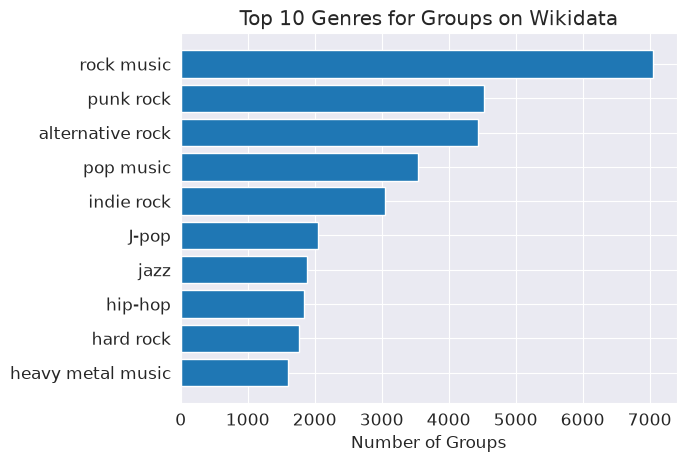

In [54]:
#Most Popular genres

genres = groupDF.select(
    pl.col("genre"),
    pl.col("genreLabel"),
    pl.col("group"),
).unique()

makeTop10(genres, "group", "genre", "genreLabel", "Wikidata", "Top 10 Genres for Groups on Wikidata")



There are 1231 genres for groups on Wikipedia.
shape: (1_231, 2)
┌────────────┬──────────┐
│ genre      ┆ fraction │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ Q11366     ┆ 0.069767 │
│ Q3071      ┆ 0.057456 │
│ Q11399     ┆ 0.051107 │
│ Q183504    ┆ 0.047046 │
│ Q37073     ┆ 0.042429 │
│ …          ┆ …        │
│ Q1191923   ┆ 0.000021 │
│ Q6184945   ┆ 0.000021 │
│ Q1482325   ┆ 0.000021 │
│ Q121306892 ┆ 0.000021 │
│ Q1564596   ┆ 0.000021 │
└────────────┴──────────┘
shape: (5, 3)
┌─────────┬──────────────────┬───────┐
│ genre   ┆ genreLabel       ┆ group │
│ ---     ┆ ---              ┆ ---   │
│ str     ┆ str              ┆ u32   │
╞═════════╪══════════════════╪═══════╡
│ null    ┆ null             ┆ 15800 │
│ Q11366  ┆ alternative rock ┆ 3264  │
│ Q3071   ┆ punk rock        ┆ 2688  │
│ Q11399  ┆ rock music       ┆ 2391  │
│ Q183504 ┆ indie rock       ┆ 2201  │
└─────────┴──────────────────┴───────┘


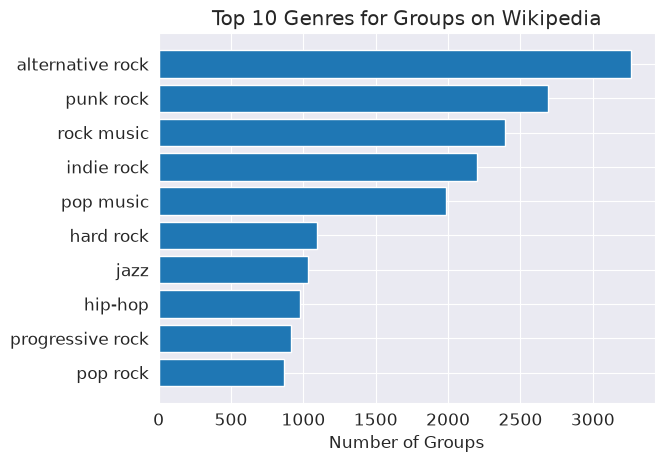

In [55]:
#Groups on Wikipedia

genres = groupDF.filter(pl.col("article").is_not_null()).select(
    pl.col("genre"),
    pl.col("genreLabel"),
    pl.col("group"),
).unique()

makeTop10(genres, "group", "genre", "genreLabel", "Wikipedia", "Top 10 Genres for Groups on Wikipedia")